# Imports

In [ ]:
'''
******************************************************************************

Kaggle's web for dataset
    https://www.kaggle.com/datasets/uciml/news-aggregator-dataset
UCI dataset
    https://archive.ics.uci.edu/ml/datasets/News+Aggregator
Script adapted from Original example:
    https://developer.nvidia.com/blog/faster-text-classification-with-naive-bayes-and-gpus/

Definiciones:
    Multinomial: https://es.wikipedia.org/wiki/Distribuci%C3%B3n_multinomial
    Bernoulli: https://es.wikipedia.org/wiki/Distribuci%C3%B3n_Bernoulli
    Gaussiana: https://es.wikipedia.org/wiki/Distribuci%C3%B3n_normal
    Categórica: https://es.wikipedia.org/wiki/Distribuci%C3%B3n_categ%C3%B3rica
    Binomial: https://es.wikipedia.org/wiki/Distribuci%C3%B3n_binomial

    https://medium.com/datos-y-ciencia/algoritmos-naive-bayes-fudamentos-e-implementaci%C3%B3n-4bcb24b307f
    https://towardsdatascience.com/tf-idf-simplified-aba19d5f5530
'''


In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB as GaussianNB_sk
from sklearn.naive_bayes import BernoulliNB as BernoulliNB_sk
from sklearn.naive_bayes import CategoricalNB as CategoricalNB_sk
from sklearn.naive_bayes import MultinomialNB as MultinomialNB_sk
from sklearn.naive_bayes import ComplementNB as ComplementNB_sk

%matplotlib inline

In [ ]:
'''
from google.colab import files
files.upload()
'''

Saving archive.zip to archive.zip
Buffered data was truncated after reaching the output size limit.

# Loading News Aggregator dataset

In [2]:
# https://archive.ics.uci.edu/dataset/359/news+aggregator

#path = 'archive.zip'
path1='https://github.com/palasatenea66/DATASETS/raw/main/news1.zip'
data1=pd.read_csv(path1)
data1

,ID,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
0,1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
1,2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
2,3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
3,4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
4,5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027
...,...,...,...,...,...,...,...,...
211463,211909,SAC's Steinberg Gets 3-1/2 Years in Prison for...,http://www.foxbusiness.com/markets/2014/05/16/...,Fox Business,b,dQSb95XREpqpurMW-SwAf3xOSMvtM,www.foxbusiness.com,1400369371775
211464,211910,UPDATE 2-SAC's Steinberg gets 3-1/2 years pris...,http://www.reuters.com/article/2014/05/16/sac-...,Reuters,b,dQSb95XREpqpurMW-SwAf3xOSMvtM,www.reuters.com,1400369371990
211465,211911,SAC's Steinberg Sentenced To 3 1/2 Years In Pr...,http://www.law360.com/securities/articles/5380...,Law360 \(subscription\),b,dQSb95XREpqpurMW-SwAf3xOSMvtM,www.law360.com,1400369372206
211466,211912,"Duly Noted: Steinberg, former SAC Capital trad...",http://www.bizjournals.com/newyork/news/2014/0...,New York Business Journal,b,dQSb95XREpqpurMW-SwAf3xOSMvtM,www.bizjournals.com,1400369372425


In [3]:
path2='https://github.com/palasatenea66/DATASETS/raw/main/news2.zip'
data2=pd.read_csv(path2)
data2

,ID,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
0,211914,Michael Steinberg of SAC Capital sentenced to ...,http://www.theguardian.com/business/2014/may/1...,The Guardian,b,dQSb95XREpqpurMW-SwAf3xOSMvtM,www.theguardian.com,1400369373107
1,211915,Steinberg Gets 3.5 Years In SAC Capital Inside...,http://www.valuewalk.com/2014/05/steinberg-get...,ValueWalk,b,dQSb95XREpqpurMW-SwAf3xOSMvtM,www.valuewalk.com,1400369373596
2,211916,SAC's Steinberg gets 3-1/2 years prison for in...,https://uk.finance.yahoo.com/news/sacs-steinbe...,Yahoo Finance UK,b,dQSb95XREpqpurMW-SwAf3xOSMvtM,uk.finance.yahoo.com,1400369373939
3,211917,SAC's Steinberg Gets 3 ½ Years as Insider Prob...,http://www.ohio.com/news/nation/sac-s-steinber...,Akron Beacon Journal,b,dQSb95XREpqpurMW-SwAf3xOSMvtM,www.ohio.com,1400369374204
4,211918,SAC Capital portfolio manager sentenced to 3 y...,http://www.whig.com/story/25537592/sac-capital...,Quincy Herald Whig,b,dQSb95XREpqpurMW-SwAf3xOSMvtM,www.whig.com,1400369374503
...,...,...,...,...,...,...,...,...
210946,422933,Surgeons to remove 4-year-old's rib to rebuild...,http://www.cbs3springfield.com/story/26378648/...,WSHM-TV,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.cbs3springfield.com,1409229190251
210947,422934,Boy to have surgery on esophagus after battery...,http://www.wlwt.com/news/boy-to-have-surgery-o...,WLWT Cincinnati,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.wlwt.com,1409229190508
210948,422935,Child who swallowed battery to have reconstruc...,http://www.newsnet5.com/news/local-news/child-...,NewsNet5.com,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.newsnet5.com,1409229190771
210949,422936,Phoenix boy undergoes surgery to repair throat...,http://www.wfsb.com/story/26368078/phoenix-boy...,WFSB,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.wfsb.com,1409229191071


In [4]:
dataset=pd.concat([data1,data2], ignore_index=True)
dataset

,ID,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
0,1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
1,2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
2,3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
3,4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
4,5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027
...,...,...,...,...,...,...,...,...
422414,422933,Surgeons to remove 4-year-old's rib to rebuild...,http://www.cbs3springfield.com/story/26378648/...,WSHM-TV,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.cbs3springfield.com,1409229190251
422415,422934,Boy to have surgery on esophagus after battery...,http://www.wlwt.com/news/boy-to-have-surgery-o...,WLWT Cincinnati,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.wlwt.com,1409229190508
422416,422935,Child who swallowed battery to have reconstruc...,http://www.newsnet5.com/news/local-news/child-...,NewsNet5.com,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.newsnet5.com,1409229190771
422417,422936,Phoenix boy undergoes surgery to repair throat...,http://www.wfsb.com/story/26368078/phoenix-boy...,WFSB,m,dpcLMoJD69UYMXMxaoEFnWql9YjQM,www.wfsb.com,1409229191071



Then we check the class distribution...

In [5]:
# business; technology; entertainment; health=medicin
dataset['CATEGORY'] = dataset.CATEGORY.map({ 'b': 1, 't': 2, 'e': 3, 'm': 4 })
dataset.head()

,ID,TITLE,URL,PUBLISHER,CATEGORY,STORY,HOSTNAME,TIMESTAMP
0,1,"Fed official says weak data caused by weather,...",http://www.latimes.com/business/money/la-fi-mo...,Los Angeles Times,1,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.latimes.com,1394470370698
1,2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,1,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207
2,3,US open: Stocks fall after Fed official hints ...,http://www.ifamagazine.com/news/us-open-stocks...,IFA Magazine,1,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371550
3,4,"Fed risks falling 'behind the curve', Charles ...",http://www.ifamagazine.com/news/fed-risks-fall...,IFA Magazine,1,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.ifamagazine.com,1394470371793
4,5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,1,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027


In [6]:
# Class distribution
dataset['CATEGORY'].value_counts()

,count
CATEGORY,
3,152469
1,115967
2,108344
4,45639


...split into training and test datasets...

In [7]:
Y, X = dataset['CATEGORY'], dataset['TITLE']
le = LabelEncoder()
y = le.fit_transform(Y)

X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, random_state=1, stratify=y)

...and check the sparsity of the data

In [8]:
vec = TfidfVectorizer(stop_words='english', ngram_range=(1,1))
x_train = vec.fit_transform(X_train_text)
x_test = vec.transform(X_test_text)

# Print sparsity of train and test
print(x_train.nnz / (x_train.shape[0] * x_train.shape[1])*100)
print(x_test.nnz / (x_test.shape[0] * x_test.shape[1])*100)
print(type(x_train))

0.013528807518777329
0.013420353576295799
<class 'scipy.sparse._csr.csr_matrix'>


In [9]:
x_train.shape

(316814, 49228)

# Gaussian NB

Transform the text through a TF-IDF vectorizer and iterate through the dataset to do multiple partial fits of Gaussian naive Bayes.

In [10]:
vec1 = TfidfVectorizer(stop_words='english', ngram_range=(1,3), min_df=5)
x_train1 = vec1.fit_transform(X_train_text)
x_test1 = vec1.transform(X_test_text)


In [11]:
print(x_train1.shape)
print(type(x_train1))

(316814, 101709)
<class 'scipy.sparse._csr.csr_matrix'>


In [12]:
def dataset_traversal(X, Y, partial_function):
    chunk_size = 5000
    classes = np.unique(Y)
    lower = 0
    for upper in iter(range(chunk_size, X.shape[0], chunk_size)):
        partial_function(X[lower:upper], Y[lower:upper], classes)
        lower = upper
    partial_function(X[upper:], Y[upper:], classes)

gnb = GaussianNB_sk()
%time dataset_traversal(x_train1,\
                        y_train,\
                        lambda x, y, c: gnb.partial_fit(x.toarray(), y, c))

%time dataset_traversal(x_test1,\
                        y_test,\
                        lambda x, y, c: print(gnb.score(x.toarray(), y)))


CPU times: user 5min 14s, sys: 3min 8s, total: 8min 23s
Wall time: 8min 28s
0.8976
0.889
0.8896
0.8916
0.8928
0.8986
0.8922
0.8874
0.8824
0.894
0.896
0.8938
0.8858
0.8886
0.895
0.8976
0.8958
0.8916
0.8888
0.898
0.8958
0.8925619834710744
CPU times: user 2min 51s, sys: 2min 19s, total: 5min 10s
Wall time: 5min 11s


# Bernoulli + CountVectorizer


In the Bernoulli variant, the feature vector is binarized. That's why using a CountVectorizer transformer is useful: You're more interested in the presence of the word rather than it's frequency.

In [13]:
vec2 = CountVectorizer(stop_words='english', binary=True, ngram_range=(1,3))

x_train2 = vec2.fit_transform(X_train_text)
x_test2 = vec2.transform(X_test_text)

bnb = BernoulliNB_sk()
%time bnb.fit(x_train2, y_train)
%time print(f'Score para BN Bernoulli {bnb.score(x_test2, y_test)}')

CPU times: user 340 ms, sys: 126 ms, total: 466 ms
Wall time: 468 ms
Score para BN Bernoulli 0.8704133327020501
CPU times: user 205 ms, sys: 53.8 ms, total: 258 ms
Wall time: 255 ms


# TF-IDF + Multinomial

Transform the text through a TF-IDF vectorizer, and run a multinomial naive Bayes model.

In [14]:
vec3 = TfidfVectorizer(stop_words='english', ngram_range=(1,3))
x_train3 = vec3.fit_transform(X_train_text)
x_test3 = vec3.transform(X_test_text)

mnb = MultinomialNB_sk()
%time mnb.fit(x_train3, y_train)
%time print(f'Score para BN Multinomial {mnb.score(x_test3, y_test)}')

CPU times: user 285 ms, sys: 180 ms, total: 465 ms
Wall time: 474 ms
Score para BN Multinomial 0.9338194214289096
CPU times: user 91.5 ms, sys: 11.2 ms, total: 103 ms
Wall time: 107 ms


# CountVectorizer + Complement
Complement naive Bayes models should be coupled with a CountVectorizer to have the best results.

CATEGORY
3    0.360943
1    0.274531
2    0.256485
4    0.108042
Name: count, dtype: float64


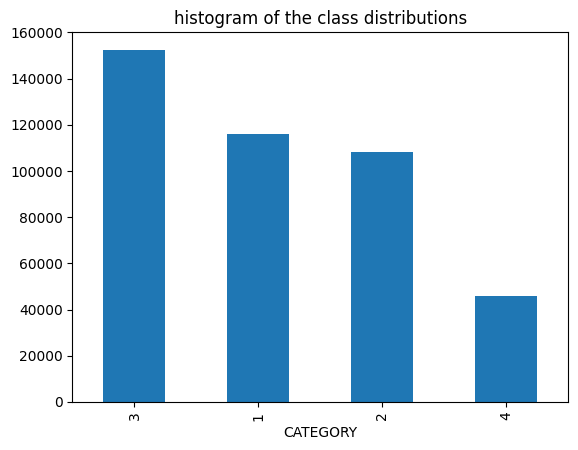

In [15]:
# First let's visualize the class imbalance

dataset['CATEGORY'].value_counts().plot(kind='bar', title='histogram of the class distributions')
print(dataset['CATEGORY'].value_counts() / len(dataset))

In [16]:
vec4 = CountVectorizer(stop_words='english', ngram_range=(1,3))
x_train4 = vec4.fit_transform(X_train_text)
x_test4 = vec4.transform(X_test_text)

cnb = ComplementNB_sk()
%time cnb.fit(x_train4, y_train)
%time print(f'Score para BN Complement {cnb.score(x_test4, y_test)}')

CPU times: user 304 ms, sys: 158 ms, total: 463 ms
Wall time: 459 ms
Score para BN Complement 0.9540646749680413
CPU times: user 46.6 ms, sys: 12.3 ms, total: 58.9 ms
Wall time: 58.6 ms


# Categorical

To transform the text to categorical data, you can apply a clustering technique to merge the terms that are similar.

To create these clusters, you could reuse a previously fitted naive Bayes model but just for the purpose of clustering those words.

## Preprocessing

In [17]:
# First fit a TfIdf on the train dataset
tfidfvec = TfidfVectorizer(stop_words='english', min_df=10)
x_train5 = tfidfvec.fit_transform(X_train_text)

# Fit a Multinomial on the TdIdf data
mnb2 = MultinomialNB_sk().fit(x_train5, y_train)


In [18]:
# Use a KMeans algorithm to cluster on what the Multinomial NB learned of the TfIdf.
# This means that the words that contribute similarly to a category will be clustered together
km = KMeans(n_clusters=1000, random_state=1)
feature_to_cluster = km.fit_predict(mnb2.feature_log_prob_.T)

print(type(feature_to_cluster))         # nparray
print(type(mnb2.feature_log_prob_.T) )   # nparray
print((mnb2.feature_log_prob_.T).shape)  # (14967,4)
print((feature_to_cluster).shape)       # (14967,)
print(feature_to_cluster)               # indica el cluster al que pertenece cada elemento

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(14967, 4)
(14967,)
[314 639   0 ... 163 860 804]


In [19]:
feats2cluster = OneHotEncoder().fit_transform(feature_to_cluster.reshape(-1, 1))

print(type(feats2cluster))  # <class 'scipy.sparse._csr.csr_matrix'>
print(feats2cluster.shape)  # (14967, 1000)


<class 'scipy.sparse._csr.csr_matrix'>
(14967, 1000)


In [20]:
feats2cluster=feats2cluster.toarray()
print(feats2cluster.shape)  # (14967, 1000)
print(feats2cluster)

(14967, 1000)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [21]:
# Print statistics on the repartition of the words in the clusters
print(pd.Series(feats2cluster.sum(axis=0)).describe())
print(pd.Series(feats2cluster.sum(axis=0)))

count    1000.00000
mean       14.96700
std        18.75515
min         1.00000
25%         6.00000
50%        11.00000
75%        17.00000
max       230.00000
dtype: float64
0      230.0
1       24.0
2       37.0
3       72.0
4       10.0
       ...  
995     12.0
996     16.0
997      1.0
998      3.0
999     13.0
Length: 1000, dtype: float64


Here each cluster holds in average around 15 words

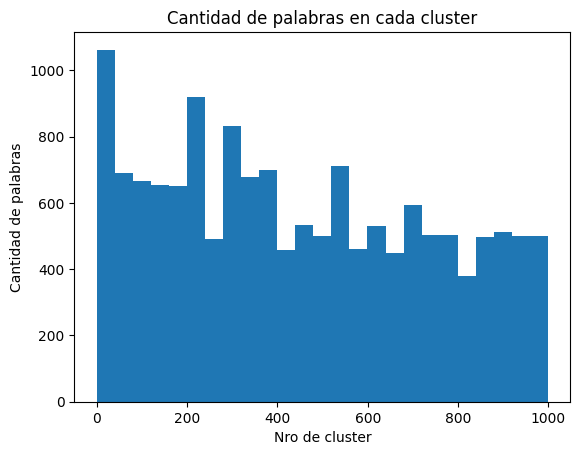

In [22]:
# Lets plot the repartition of the words in each cluster
# And print the words in a few clusters
plt.hist(feature_to_cluster, bins='auto')
plt.title('Cantidad de palabras en cada cluster')
plt.xlabel('Nro de cluster')
plt.ylabel('Cantidad de palabras')
plt.show()


In [23]:
print(len(tfidfvec.vocabulary_))  # 14967
print(tfidfvec.vocabulary_)

14967
{'apple': 1081, 'agrees': 765, 'pay': 9784, '450m': 322, 'settlement': 11957, 'ebook': 4522, 'price': 10370, 'fixing': 5370, 'case': 2444, 'movie': 8866, 'review': 11293, 'transformers': 13711, 'age': 746, 'extinction': 5024, 'saved': 11697, 'veterans': 14273, 'mark': 8290, '10': 12, 'record': 10903, 'stores': 12837, 'metro': 8546, 'phoenix': 9945, 'zenimax': 14942, 'drags': 4338, 'oculus': 9313, 'vr': 14411, 'court': 3361, 'rift': 11361, 'headset': 6341, 'dispute': 4147, 'game': 5725, 'thrones': 13494, 'burning': 2229, 'questions': 10665, 'finale': 5294, 'durable': 4446, 'goods': 5951, 'orders': 9459, 'jump': 7357, 'march': 8267, 'french': 5604, 'market': 8293, 'lower': 8080, 'plunges': 10110, 'jeopardy': 7252, 'champ': 2567, 'unseated': 14084, '11': 37, 'winning': 14697, 'streak': 12861, 'women': 14746, 'comic': 2991, 'protest': 10515, 'harassment': 6250, 'nadine': 8963, 'gordimer': 5961, 'nobel': 9159, 'prize': 10403, 'author': 1334, 'apartheid': 1045, 'dies': 4016, '90': 478,

In [24]:
tfidfvec_pd=pd.DataFrame(tfidfvec.vocabulary_.keys(), index=(tfidfvec.vocabulary_).values(), columns=['words'])
print(tfidfvec_pd.shape)
print(tfidfvec_pd.head())

(14967, 1)
            words
1081        apple
765        agrees
9784          pay
322          450m
11957  settlement


In [25]:
#%%   cell 22.2  vemos cómo ubicamos la posición de cada palabra en la consulta np.where
print(np.where(feature_to_cluster == 127))
print((np.where(feature_to_cluster == 632)))
print((np.where(feature_to_cluster == 127))[0])
print((np.where(feature_to_cluster == 127))[0][0])

(array([ 2448,  2699,  4125,  6467,  7267,  9507,  9923, 11559, 13675,
       13868]),)
(array([  773,   910,  1529,  2112,  2887,  2959,  3163,  3575,  3733,
        3861,  4979,  4984,  7442,  8294,  8356,  9256,  9578, 12988,
       13532]),)
[ 2448  2699  4125  6467  7267  9507  9923 11559 13675 13868]
2448


In [26]:
#%%    cell 22.3         ahora accedemos a la palabra a través de su posición
print(tfidfvec_pd.iloc[ (np.where(feature_to_cluster == 127)[0][0]),:])
print("\n")
print(tfidfvec_pd.iloc[(np.where(feature_to_cluster == 632)[0][0]),:])

words    paid
Name: 9623, dtype: object


words    old
Name: 9363, dtype: object


In [27]:
# For Categorical Naive Bayes, the count of words is transformed into a count of cluster
vocab = tfidfvec.vocabulary_
countvec = CountVectorizer(stop_words='english')
countvec.vocabulary_ = vocab

x_train6 = countvec.transform(X_train_text)
x_test6 = countvec.transform(X_test_text)
print(x_train6.shape)
print(feats2cluster.shape)

x_train_cluster = (x_train6 @ feats2cluster)
x_test_cluster = (x_test6 @ feats2cluster)

print(type(x_train_cluster))
print(x_train_cluster.shape)
print(x_train_cluster)

(316814, 14967)
(14967, 1000)
<class 'numpy.ndarray'>
(316814, 1000)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [28]:
# For each cluster we will have:
# - 0: absence of those words.
# - 1: presence of those words
# - 2: multiple presence of those words (2+)

x_train_cluster[x_train_cluster > 2] = 2
x_test_cluster[x_test_cluster > 2] = 2

Little hack to make sure that if a cluster's max number is 1 in training, it is also 1 in testing

In [29]:
print(np.where(x_train_cluster.max(0) == 1))

(array([ 18,  24,  34,  50,  54,  98, 109, 116, 129, 132, 138, 149, 151,
       156, 163, 217, 219, 230, 235, 241, 273, 284, 328, 334, 342, 346,
       360, 371, 379, 389, 395, 419, 423, 438, 440, 444, 466, 481, 483,
       496, 519, 523, 539, 544, 552, 556, 563, 565, 578, 594, 607, 623,
       635, 646, 663, 665, 681, 694, 697, 698, 699, 700, 716, 727, 733,
       736, 742, 757, 759, 764, 770, 787, 791, 805, 812, 834, 849, 854,
       861, 921, 922, 944, 949, 954, 963, 968, 970, 972, 975, 979, 991]),)


In [30]:
max_one = np.where(x_train_cluster.max(0) == 1)[0]
print(len(max_one))       # 97
print(max_one.shape)

for cluster in max_one:
    samples = (x_test_cluster[:, cluster] > 1)   # nparray tipo máscara, los elementos son True-False
    samples = np.where(samples)[0]
    x_test_cluster[samples, cluster] = 1

91
(91,)


## Categorical model training

Now that the preprocessing is done we can train the Categorical model and see how it performs on these clusters

In [31]:
%time cnb = CategoricalNB_sk().fit(x_train_cluster, y_train)
%time print(f'Score de Categorical NB {cnb.score(x_test_cluster, y_test)}')

CPU times: user 18.7 s, sys: 772 ms, total: 19.5 s
Wall time: 19.6 s
Score de Categorical NB 0.9262156147909664
CPU times: user 7.45 s, sys: 179 ms, total: 7.63 s
Wall time: 7.64 s


# Performance gain
## Gráfico de comparación entre los tiempos de procesamiento sobre los mismos modelos de la CPU con sklearn y la GPU de Nvidia con cuML


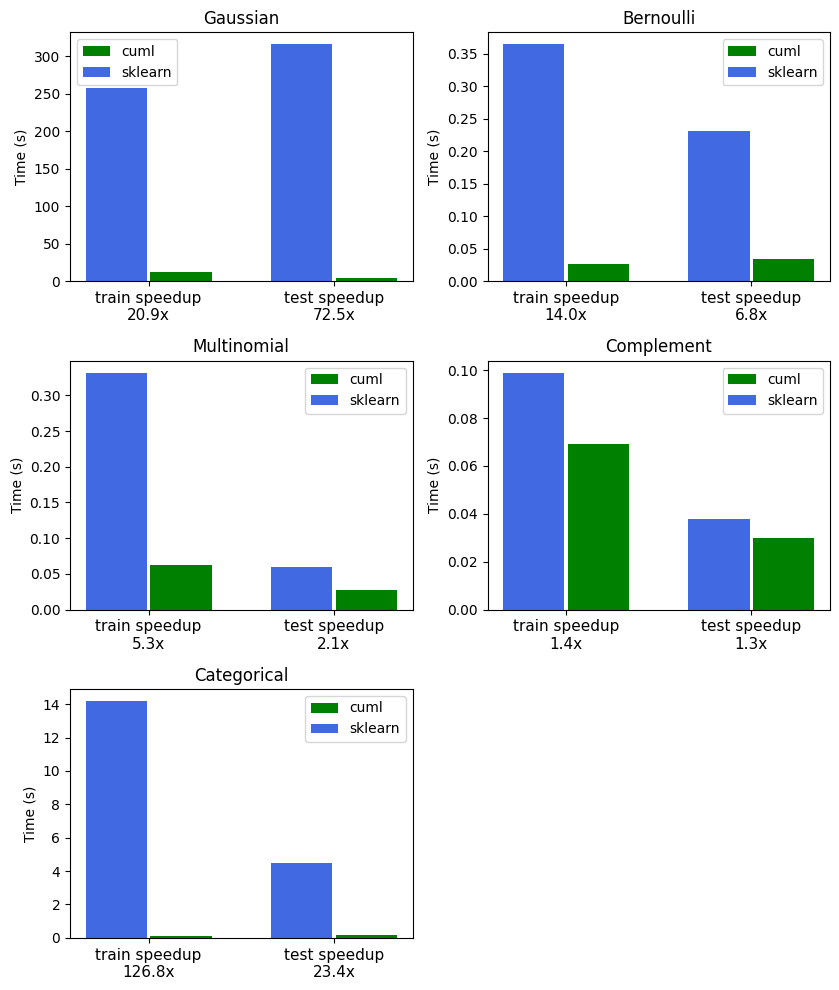

In [32]:
variants = ['Gaussian', 'Bernoulli', 'Multinomial', 'Complement', 'Categorical']
time_training_cuml = np.array([12300,  26,  63,  69,  112]) / 1000
time_testing_cuml  = np.array([4360,   34,  28,  30,  193])/ 1000
time_training_sk   = np.array([257000, 365, 332, 99, 14200])/ 1000
time_testing_sk    = np.array([316000, 231, 59,  38,  4510])/ 1000
training_gain = time_training_sk / time_training_cuml
testing_gain = time_testing_sk / time_testing_cuml

x = np.arange(2)  # the label locations
width = 0.33  # the width of the bars
fig = plt.figure(figsize=(8.5,10))

for i in range(5):
    ax = plt.subplot(3,2,i+1)
    ax.bar(x[0] + width/2 + 0.01, time_training_cuml[i], width, color='green')
    ax.bar(x[0] - width/2 - 0.01, time_training_sk[i], width, color='royalblue')
    ax.bar(x[1] + width/2 + 0.01, time_testing_cuml[i], width, color='green')
    ax.bar(x[1] - width/2 - 0.01, time_testing_sk[i], width, color='royalblue')

    ax.set_ylabel('Time (s)')
    ax.set_title(variants[i])
    ax.set_xticks(x)
    ax.set_xticklabels(["train speedup\n{:.1f}x".format(training_gain[i]),
                        "test speedup\n{:.1f}x".format(testing_gain[i])],
                      fontdict={'fontsize': 11,})
    ax.legend(['cuml', 'sklearn'])

fig.tight_layout()

plt.show()